In [1]:
# Phase (I): Test GRPO on Game of 24 — surface drawbacks D1-D4
#
#   D1  CoT redundancy           → track CoT length distribution across training
#   D2  No per-token signal      → (structural; visualised by absence of v_t)
#   D3  Zero-pass@K dead zone    → curate hard puzzles, track which never solve
#   D4  Indiscriminate credit    → inspect failed rollouts that share good prefixes
#
# Phase (II) [later]: swap reward + advantage for velocity / answer-buffer / prefix-buffer
#                     and re-run the same diagnostics to verify the four fixes.

In [2]:
import os, re, json, random, itertools, math
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from trl import GRPOTrainer, GRPOConfig

os.environ.setdefault("HF_HUB_ENABLE_HF_TRANSFER", "1")
random.seed(0); np.random.seed(0); torch.manual_seed(0)

MODEL_NAME    = "Qwen/Qwen3-0.6B"
OUTPUT_DIR    = Path("output/game24_grpo_baseline")
ROLLOUT_LOG   = OUTPUT_DIR / "rollouts.jsonl"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output dir:", OUTPUT_DIR.resolve())

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

objc[84904]: Class AVFFrameReceiver is implemented in both /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/av/.dylibs/libavdevice.61.1.100.dylib (0x2e7fd0798) and /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x3023343a8). One of the two will be used. Which one is undefined.
objc[84904]: Class AVFAudioReceiver is implemented in both /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/av/.dylibs/libavdevice.61.1.100.dylib (0x2e7fd07e8) and /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x3023343f8). One of the two will be used. Which one is undefined.


Output dir: /Users/fangyuanyu/Implementation/arl/output/game24_grpo_baseline


## 2. Game-of-24 &nbsp;·&nbsp; data &nbsp;·&nbsp; rewards

Everything in this section is a thin wrapper around `src.game24utils`:

- **verifier + solver** — `verify_24`, `enumerate_solutions` (canonical distinct-solution count: associativity + commutativity collapsed, e.g. `(2,4,8,10)` → 11)
- **puzzle pool** — `build_puzzle_pool`
- **split** — `split_train_eval` (flat train/eval; validation = `max(40% of total, 400)`)
- **prompts / datasets** — `SYSTEM_PROMPT`, `to_chat`, `make_dataset`
- **rewards** — `correctness_reward`, `format_reward`

The notebook itself focuses on training, diagnostics, and the velocity-reward
analysis. Algorithm pieces stay here; bookkeeping pieces live in the module.

In [ ]:
from src.game24utils import (
    verify_24,
    build_puzzle_pool, split_train_eval, make_dataset,
    to_chat,
    _text, extract_expr,
    correctness_reward, format_reward,
)

# All solvable 4-tuples from digits 1..max_n, with the CANONICAL distinct-
# solution count (associativity + commutativity collapsed).
puzzles = build_puzzle_pool(max_n=13)
print(f"Solvable 4-tuples (max_n=13): {len(puzzles)}")
print("example puzzle:", puzzles[0])

Solvable 4-tuples: 1362
  easy   (≥8 sols): 1107
  medium (3-7 sols): 169
  hard   (≤2 sols): 86
example hard puzzle: {'numbers': [1, 1, 1, 13], 'solutions': ['(1+1)*(13-1)', '(13-1)*(1+1)'], 'n_solutions': 2}


In [ ]:
# Flat train/eval split (no difficulty buckets, no probe).
# Validation size = max(40% of total, 400), capped at N; remainder is training.
train_puzzles, eval_puzzles = split_train_eval(puzzles, eval_frac=0.40, eval_min=400)
print(f"train={len(train_puzzles)}, eval={len(eval_puzzles)}")

train_ds, eval_ds = make_dataset(train_puzzles), make_dataset(eval_puzzles)
print(train_ds[0])

train=356, eval=38, probe(hard, held-out)=10
{'prompt': [{'content': "You play the Game of 24. Given four numbers, you must write a single arithmetic expression using each number exactly once with + - * / and parentheses that evaluates to 24.\n\nThink step by step. First reason about how to combine the numbers, then on the final line output only the expression after '#### '.\nExample final line: '#### (3+5)*(7-4)'.", 'role': 'system'}, {'content': "Given numbers: 3,3,5,9. Make 24. Think step by step, then give your final expression on the last line after '#### '.", 'role': 'user'}], 'numbers': [3, 3, 5, 9], 'solutions': ['((3+5)/3)*9', '(3+5)/(3/9)', '((3+5)*9)/3', '(3+5)*(9/3)', '3*(5+(9/3))', '(9+3)*(5-3)', '(9*(3+5))/3', '9*((3+5)/3)', '((9/3)+5)*3', '(9/3)*(5+3)', '9/(3/(5+3))', '3*((9/3)+5)', '((5+3)*9)/3', '(5+3)*(9/3)', '(5-3)*(9+3)', '(5+(9/3))*3', '(3+3)*(9-5)', '(9/3)*(3+5)', '9/(3/(3+5))', '(9-5)*(3+3)', '(9*(5+3))/3', '9*((5+3)/3)', '((5+3)/3)*9', '(5+3)/(3/9)', '(5-3)*(3+9

In [4]:
# Rewards live in src.game24utils — trajectory-level only (D2 is structural).
# Sanity:
fake = [[{"role": "assistant", "content": "Let me think...\n#### (3+5)*(7-4)"}]]
print("correctness:", correctness_reward(fake, numbers=[[3, 5, 7, 4]]))
print("format    :", format_reward(fake))

correctness: [1.0]
format    : [0.2]


In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class RolloutLogger:
    """Logs every rollout to JSONL via the reward-fn callback. Returns 0.0 reward."""
    def __init__(self, path: Path, tok):
        self.path = path
        self.tok  = tok
        self.step = 0
        self.path.write_text("")  # truncate

    def __call__(self, completions, numbers, solutions=None, **kwargs):
        with self.path.open("a") as f:
            for i, (c, nums) in enumerate(zip(completions, numbers)):
                text = _text(c)
                expr = extract_expr(text)
                correct = verify_24(list(nums), expr)
                n_tok = len(self.tok.encode(text, add_special_tokens=False))
                f.write(json.dumps({
                    "step": self.step,
                    "idx": i,
                    "numbers": list(nums),
                    "completion": text,
                    "expr": expr,
                    "correct": bool(correct),
                    "n_tokens": int(n_tok),
                }) + "\n")
        self.step += 1
        return [0.0] * len(completions)   # passthrough, contributes nothing

    # Keep TRL happy: it inspects __name__ on reward callables.
    __name__ = "rollout_logger"

rollout_logger = RolloutLogger(ROLLOUT_LOG, tokenizer)
print("Rollout log →", ROLLOUT_LOG)

Rollout log → output/game24_grpo_baseline/rollouts.jsonl


## 5. Train &nbsp;·&nbsp; vanilla GRPO

Short run (200 steps, 8 generations/prompt) is enough to surface the four
drawbacks. Bump `max_steps` for a longer collapse-watch.

In [ ]:
config = GRPOConfig(
    output_dir=str(OUTPUT_DIR),
    num_generations=8,
    max_completion_length=512,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=5e-6,
    max_steps=200,
    logging_steps=5,
    bf16=True,
    save_strategy="no",
    report_to="none",
    use_vllm=True,
    vllm_mode="colocate",
    vllm_gpu_memory_utilization=0.4,
)

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16)

trainer = GRPOTrainer(
    model=model,
    reward_funcs=[correctness_reward, format_reward, rollout_logger],
    args=config,
    train_dataset=train_ds,
)
trainer.train()
print("Done. Rollouts at:", ROLLOUT_LOG)

## 6. Per-token reward GRPO (implementation pattern)

In [ ]:
import re
from pathlib import Path

import numpy as np
import torch

from src.pertoken_trainer import PerTokenAdvantageTrainer
from src.online_buffer    import OnlineBuffer
from src.velocity         import VelocityRewardComputer
from src.prefix_inject    import PrefixInjector


# -----------------------------------------------------------------------------
# (1) Placeholder per-token reward (sanity baseline; not used when USE_VELOCITY).
# -----------------------------------------------------------------------------
_NUM_RE = re.compile(r"Given numbers:\s*([\d,\s]+)")


def _numbers_from_prompt_text(text: str):
    m = _NUM_RE.search(text)
    return [int(x) for x in m.group(1).split(",")] if m else []


def _numbers_from_prompt_ids(prompt_ids, tokenizer):
    return [
        _numbers_from_prompt_text(tokenizer.decode(pid, skip_special_tokens=True))
        for pid in prompt_ids
    ]


def placeholder_per_token_reward(prompt_ids, completion_ids, completion_mask, *, tokenizer):
    B, T = completion_ids.shape
    device = completion_ids.device
    numbers_per_row = _numbers_from_prompt_ids(prompt_ids, tokenizer)

    traj_r = torch.zeros(B, device=device)
    for i in range(B):
        text = tokenizer.decode(
            completion_ids[i][completion_mask[i].bool()], skip_special_tokens=True,
        )
        traj_r[i] = float(verify_24(list(numbers_per_row[i]), extract_expr(text)))

    T_eff = completion_mask.sum(dim=1).clamp(min=1).float()
    pos   = torch.arange(T, device=device, dtype=torch.float32)
    ramp  = pos.unsqueeze(0) / T_eff.unsqueeze(1)
    return ramp * traj_r.unsqueeze(1) * completion_mask.float()


# -----------------------------------------------------------------------------
# (2) Task-specific hooks for the velocity reward route.
#
#     Using the puzzle numbers tuple as the buffer key sidesteps any chat-
#     template / tokenizer mismatch between offline seeding and online lookup.
# -----------------------------------------------------------------------------
def game24_query_key(prompt_str: str):
    return tuple(_numbers_from_prompt_text(prompt_str))


def game24_is_correct(completion_str: str, prompt_str: str) -> bool:
    nums = _numbers_from_prompt_text(prompt_str)
    if not nums:
        return False
    return bool(verify_24(nums, extract_expr(completion_str)))


# -----------------------------------------------------------------------------
# (3) Online buffers + velocity reward computer.
#
#     answer_buffer  : `#### expr` strings — reference targets for velocity.
#     prefix_buffer  : full accepted CoTs — sampled as generation prefixes.
#
#     The answer buffer is seeded from the supervised solutions on each
#     training puzzle. The prefix buffer starts empty and fills online as
#     correct rollouts arrive (no SFT CoTs for Game24).
# -----------------------------------------------------------------------------
answer_buffer = OnlineBuffer(capacity_per_query=64)
prefix_buffer = OnlineBuffer(capacity_per_query=32)

_seed_n = 0
for row in train_ds:
    qk = tuple(row["numbers"])
    for expr in (row.get("solutions") or []):
        _seed_n += int(answer_buffer.add(qk, expr))
print(f"answer buffer seeded: {_seed_n} entries / {answer_buffer.num_queries()} queries")
print(f"prefix buffer starts empty (fills online from correct rollouts)")

velocity_computer = VelocityRewardComputer(
    answer_buffer,
    chunk_strategy="uniform",   # or "random"
    chunk_size=16,              # tokens per chunk
    normalize_by_chunk=True,    # Σ_t r_t = R_T per rollout
)


# -----------------------------------------------------------------------------
# (4) Wire up the trainer.
#
#     USE_VELOCITY: per-token velocity reward vs placeholder ramp.
#     USE_PREFIX  : inject sampled CoT prefixes at generation time.
#                   (Requires USE_VELOCITY=True so the prefix buffer gets fed.)
# -----------------------------------------------------------------------------
USE_VELOCITY = True
USE_PREFIX   = False    # flip to True once the velocity reward is training cleanly

PT_OUTPUT_DIR = Path("output/game24_grpo_pertoken")
PT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pt_config = GRPOConfig(
    output_dir=str(PT_OUTPUT_DIR),
    num_generations=8,
    max_completion_length=512,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=5e-6,
    max_steps=200,
    logging_steps=5,
    bf16=True,
    save_strategy="no",
    report_to="none",
    use_vllm=True,
    vllm_mode="colocate",
    vllm_gpu_memory_utilization=0.4,
    # Generous: prompt (~200) + prefix (≤512) + completion (512) + slack.
    vllm_max_model_length=2048,
)

pt_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16)

trainer_kw = dict(
    model=pt_model,
    reward_funcs=[correctness_reward, format_reward],
    args=pt_config,
    train_dataset=train_ds,
    adv_mode="token",   # or "position" / "progress" — empirical question
)
if USE_VELOCITY:
    trainer_kw.update(
        velocity_computer=velocity_computer,
        is_correct=game24_is_correct,
        query_key_fn=game24_query_key,
    )
else:
    trainer_kw.update(per_token_reward_fn=placeholder_per_token_reward)

if USE_PREFIX:
    if not USE_VELOCITY:
        raise RuntimeError(
            "USE_PREFIX requires USE_VELOCITY=True so the prefix buffer "
            "is fed by accepted rollouts inside the trainer."
        )
    trainer_kw["prefix_buffer"] = prefix_buffer
    trainer_kw["rollout_func"] = PrefixInjector(
        prefix_buffer,
        query_key_fn=game24_query_key,
        p_inject=0.5,
        truncate="uniform",
        share_within_group=True,
        rng=np.random.default_rng(0),
    )

pt_trainer = PerTokenAdvantageTrainer(**trainer_kw)
pt_trainer.train()
print("Done. Output:", PT_OUTPUT_DIR)


/Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
/Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_ref" in ModelCreateRes has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_output" in EvalResultsTrial has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/pyd

NameError: name 'Path' is not defined

In [2]:
# =============================================================================
# Test · 4 rollouts on (3,5,7,4), T differs per rollout, K=4 chunks shared.
# =============================================================================
import numpy as np
import torch
from transformers import AutoModelForCausalLM

dev = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
mdl = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float32, tie_word_embeddings=False
).to(dev).eval()
tok = tokenizer
pad = tok.pad_token_id or tok.eos_token_id

prompt   = "Given numbers: 3,5,7,4. Make 24. Final line '#### expr'.\n"
rollouts = [
    "<think>3+5=8, 7-4=3, 8*3=24. </think>",
    "<think>Try 7-4=3 then 3*5=15... no. (3+5)*(7-4)=8*3=24. </think>\n",
    "<think>3*5=15, 7+4=11, 15+11=26 close. </think>\n",
    "<think>(3+5)*(7-4) directly. </think>\n",
]
refs = ["#### (3+5)*(7-4)", "#### (5+3)*7+4","#### 5 + 3 * (7-4)", "#### (5+3)*(7 - 4)"]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

In [3]:
# =============================================================================
# Sanity check for compute_pv_reward + VelocityRewardComputer answer-token fill.
#
# Property A (compute_pv_reward, CoT only):
#   Σ_{t in CoT} r_t[b] == logp(a | q + o[:o_len_b]) − logp(a | q) ≡ R_T[b]
#
# Property B (VelocityRewardComputer, trainer-style):
#   For each rollout b:
#     • Σ_{t in CoT} r_t[b]                    == R_T[b]
#     • r_t[b, t] for every answer-marker pos  == R_T[b]   (constant per row)
#
# Same function (compute_pv_reward) under the hood — what differs between
# [A] and [B] is the (q, o, a) tokens we feed it. [A] passes clean
# string-tokenized inputs; [B] exercises the wrapper's id-space preprocessing
# (mask trim, "####" cut, ref extraction, pack).
#
# IMPORTANT: [B] builds the trainer-style completion by literal concatenation
# rollouts[b] + refs[b] — NO injected '\n', NO rstrip/lstrip. Anything else
# would test a fabricated completion that [A] never sees.
# =============================================================================
import torch
import torch.nn.functional as F

# Force a fresh import — bypasses any stale cached class from earlier runs.
import importlib, src.velocity, src.online_buffer
importlib.reload(src.velocity)
importlib.reload(src.online_buffer)
from src.velocity      import (
    build_t_grid, compute_pv_reward, pack_pv_inputs, VelocityRewardComputer,
)
from src.online_buffer import OnlineBuffer

# ── Property A: compute_pv_reward sum-invariance ─────────────────────────────
prompts = [prompt] * len(rollouts)
pv = pack_pv_inputs(prompts, rollouts, refs, tok, dev)
chunk_ends = build_t_grid(pv.o_max, strategy="uniform", n_chunks=4)
print(f"chunk_ends ({len(chunk_ends) - 1} chunks): {chunk_ends}")

r_t = compute_pv_reward(pv.qo_ids, pv.qo_mask, pv.a_ids, pv.a_mask,
                        pv.q_len, chunk_ends, mdl)

@torch.no_grad()
def _logp_a_given(prefix_ids, a_seq):
    inp = torch.tensor([prefix_ids + a_seq], device=dev)
    lp  = F.log_softmax(mdl(inp).logits.float(), dim=-1)[0]
    Lp  = len(prefix_ids)
    return float(lp[Lp - 1: Lp - 1 + len(a_seq), :].gather(
        1, torch.tensor(a_seq, device=dev).unsqueeze(1)).sum())

print(f"\n[A] compute_pv_reward sum-invariance")
print(f"{'b':>2} {'o_len':>6} {'Σ CoT r_t':>11} {'R_T direct':>12}    {'Δ':>8}")
R_T_directs = []
okA = True
for b in range(len(rollouts)):
    lq, lo = int(pv.q_len[b]), int(pv.o_len[b])
    la     = int(pv.a_mask[b].sum())
    q_ids  = pv.qo_ids[b, :lq].tolist()
    o_ids  = pv.qo_ids[b, lq:lq + lo].tolist()
    a_ids_ = pv.a_ids[b, :la].tolist()
    R_direct = (_logp_a_given(q_ids + o_ids, a_ids_)
                - _logp_a_given(q_ids,       a_ids_))
    R_T_directs.append(R_direct)
    R_sum    = float(r_t[b, :lo].sum())
    delta    = R_sum - R_direct
    okA     &= abs(delta) < 1e-2
    print(f"{b:>2} {lo:>6} {R_sum:>+11.3f} {R_direct:>+12.3f}    {delta:>+8.4f}")

print(f"\n[A] {'PASSED ✓' if okA else 'FAILED ✗'}")

# ── Property B: VelocityRewardComputer fills answer tokens with R_T ──────────
# Trainer-style completion = literal rollout + ref. No mangling.
completions_full = [rollouts[b] + refs[b] for b in range(len(rollouts))]

p_raw = [tok(p, add_special_tokens=False).input_ids for p in prompts]
c_raw = [tok(c, add_special_tokens=False).input_ids for c in completions_full]
Bp    = len(completions_full)
Pmax  = max(len(p) for p in p_raw)
Tmax  = max(len(c) for c in c_raw)

prompt_ids_pad      = torch.full ((Bp, Pmax), pad, device=dev, dtype=torch.long)
completion_ids_pad  = torch.full ((Bp, Tmax), pad, device=dev, dtype=torch.long)
completion_mask_pad = torch.zeros((Bp, Tmax),      device=dev, dtype=torch.long)
for b in range(Bp):
    lp, lc = len(p_raw[b]), len(c_raw[b])
    prompt_ids_pad    [b, :lp] = torch.tensor(p_raw[b], device=dev)
    completion_ids_pad[b, :lc] = torch.tensor(c_raw[b], device=dev)
    completion_mask_pad[b, :lc] = 1

vrc = VelocityRewardComputer(
    OnlineBuffer(capacity_per_query=4),
    chunk_strategy="uniform", n_chunks=4, normalize_by_chunk=True,
)
r_t_w, cot_m = vrc.compute_per_token_reward(
    prompt_ids_pad, completion_ids_pad, completion_mask_pad,
    model=mdl, tokenizer=tok,
    query_keys=list(range(Bp)),
    correctness=[True] * Bp,
)

print(f"\n[B] VelocityRewardComputer per-token reward shape: {tuple(r_t_w.shape)}")
print(f"{'b':>2} {'Σ CoT r_t':>11} {'ans-tok r_t':>12} {'R_T direct':>12} "
      f"{'Δ_cot':>8} {'Δ_ans':>8}  {'ans uniform?':>13}")
okB = True
for b in range(Bp):
    R_direct  = R_T_directs[b]
    cot_sum_b = float((r_t_w[b] * cot_m[b]).sum())
    ans_m_b   = completion_mask_pad[b].bool() & ~cot_m[b].bool()
    if ans_m_b.any():
        ans_vals = r_t_w[b][ans_m_b]
        ans_val  = float(ans_vals[0])
        uniform  = bool((ans_vals - ans_val).abs().max() < 1e-5)
    else:
        ans_val, uniform = float("nan"), False
    d_cot = cot_sum_b - R_direct
    d_ans = ans_val   - R_direct
    okB  &= abs(d_cot) < 5e-2 and abs(d_ans) < 5e-2 and uniform
    print(f"{b:>2} {cot_sum_b:>+11.3f} {ans_val:>+12.3f} {R_direct:>+12.3f} "
          f"{d_cot:>+8.4f} {d_ans:>+8.4f}  {str(uniform):>13}")

print(f"\n[B] {'PASSED ✓' if okB else 'FAILED ✗'}")
print(f"\nOverall: {'PASSED ✓' if (okA and okB) else 'FAILED ✗'}")


chunk_ends (4 chunks): [0, 10, 20, 30, 38]

[A] compute_pv_reward sum-invariance
 b  o_len   Σ CoT r_t   R_T direct           Δ
 0     24     -28.457      -28.457     -0.0000
 1     38      +3.048       +3.048     +0.0000
 2     30     -12.148      -12.148     +0.0001
 3     15      -0.819       -0.819     -0.0000

[A] PASSED ✓

[B] VelocityRewardComputer per-token reward shape: (4, 47)
 b   Σ CoT r_t  ans-tok r_t   R_T direct    Δ_cot    Δ_ans   ans uniform?
 0     -28.457      -28.457      -28.457  -0.0000  -0.0000           True
 1      +3.048       +3.048       +3.048  +0.0000  +0.0000           True
 2     -12.148      -12.148      -12.148  +0.0001  +0.0001           True
 3      -0.819       -0.819       -0.819  -0.0000  -0.0000           True

[B] PASSED ✓

Overall: PASSED ✓


In [4]:
# (Issue). Answer token should have non-zero reward
#          that equals CoT sequence's predictive reward log p(a | s, o)

# =============================================================================
# VelocityRewardComputer demo — why we need the wrapper.
#
# In the trainer (`_compute_loss`), all we get is the padded batch:
#     prompt_ids (Bp, P)     left- or right-padded
#     completion_ids (Bp, T) right-padded
#     completion_mask (Bp, T)
#     correctness    [bool]  from format/correctness reward funcs
#     query_keys     [hash]  to look up the buffer
#
# To call `compute_pv_reward` directly we'd need to, *per rollout*:
#   1) strip prompt pad,
#   2) mask-trim completion,
#   3) cut "#### ..." off the CoT (so the answer doesn't leak into o),
#   4) pick a reference: own #### if correct, else buffer.sample(),
#   5) tokenize that ref,
#   6) re-pack everything into (qo_ids, qo_mask, a_ids, a_mask, q_len),
#   7) call compute_pv_reward,
#   8) scatter the (B_valid, o_max) result back into the (Bp, T) slot,
#   9) fill answer-marker positions with R_T (cumulative velocity),
#  10) update the buffer with newly-accepted answers.
#
# That's a lot of boilerplate to wedge into a trainer's hot loop. The
# `VelocityRewardComputer` is exactly that boilerplate, kept in one place.
# =============================================================================
from src.online_buffer  import OnlineBuffer
from src.velocity       import VelocityRewardComputer

# ── 1) Build a trainer-style batch from the rollouts/refs we already have ──
nums = (3, 5, 7, 4)

# Wire each CoT to a final-answer line; flag rollout 2 as wrong on purpose.
# LITERAL concatenation — rollouts[b] already ends with whatever the model
# emitted before "####"; do not inject a synthetic '\n' or strip anything.
trainer_completions = [
    rollouts[0] + "#### (3+5)*(7-4)",   # correct
    rollouts[1] + "#### (3+5)*(7-4)",   # correct
    rollouts[2] + "#### 26",            # WRONG  (15+11=26, model got it wrong)
    rollouts[3] + "#### (5+3)*(7-4)",   # correct (equivalent form)
]
correctness = [True, True, False, True]
query_keys  = [nums] * len(trainer_completions)

# Tokenize as the trainer would (right-padded prompt_ids + completion_ids).
p_raw = [tok(prompt,            add_special_tokens=False).input_ids
         for _ in trainer_completions]
c_raw = [tok(c, add_special_tokens=False).input_ids
         for c in trainer_completions]
Bp    = len(trainer_completions)
P     = max(len(p) for p in p_raw)
Tlen  = max(len(c) for c in c_raw)

prompt_ids      = torch.full ((Bp, P),    pad, device=dev, dtype=torch.long)
completion_ids  = torch.full ((Bp, Tlen), pad, device=dev, dtype=torch.long)
completion_mask = torch.zeros((Bp, Tlen),      device=dev, dtype=torch.long)
for b in range(Bp):
    lp, lc = len(p_raw[b]), len(c_raw[b])
    prompt_ids    [b, :lp] = torch.tensor(p_raw[b], device=dev)
    completion_ids[b, :lc] = torch.tensor(c_raw[b], device=dev)
    completion_mask[b, :lc] = 1

# ── 2) Online buffer pre-seeded with one accepted solution for (3,5,7,4). ──
#      In real training this is seeded from the dataset + filled by accepted
#      rollouts via `vrc.update_buffer(...)`.
buf = OnlineBuffer(capacity_per_query=64)
buf.add(nums, "(3+5)*(7-4)")
print(f"buffer seeded for {nums}: {buf.keys_for(nums)}")

# ── 3) One call. That's the whole point. ───────────────────────────────────
# Returns r_t AND cot_mask. The mask distinguishes CoT positions (per-chunk
# velocity reward) from answer-marker positions (filled with cumulative R_T).
vrc = VelocityRewardComputer(
    buf, chunk_strategy="uniform", chunk_size=4, normalize_by_chunk=True,
)
r_t, cot_mask = vrc.compute_per_token_reward(
    prompt_ids, completion_ids, completion_mask,
    model=mdl, tokenizer=tok,
    query_keys=query_keys,
    correctness=correctness,
)

print(f"\nr_t.shape = {tuple(r_t.shape)}    cot_mask.shape = {tuple(cot_mask.shape)}")
print(f"\n{'b':>2} {'correct':>8} {'Σ r_t (CoT)':>13} {'R_T (ans tok)':>15}   note")
for b in range(Bp):
    cot_sum = float((r_t[b] * cot_mask[b]).sum())
    ans_m_b = (completion_mask[b].bool() & ~cot_mask[b].bool())
    R_T_b   = float(r_t[b][ans_m_b][0]) if ans_m_b.any() else float("nan")
    note    = "scored vs own ####" if correctness[b] else "scored vs buffer sample"
    print(f"{b:>2} {str(correctness[b]):>8} {cot_sum:>+13.3f} {R_T_b:>+15.3f}   {note}")

print("\nObservations:")
print("- Σ r_t over CoT positions == R_T (sum-invariance of velocity reward).")
print("- All answer-marker positions of a rollout share the same R_T value;")
print("  they're a constant per-rollout signal of 'how confident is the model")
print("  in the reference answer given the full CoT'.")
print("- Trainer will pool CoT and answer tokens into TWO separate z-score")
print("  baselines so the two scales don't pollute each other.")

buffer seeded for (3, 5, 7, 4): ['(3+5)*(7-4)']

r_t.shape = (4, 48)    cot_mask.shape = (4, 48)

 b  correct   Σ r_t (CoT)   R_T (ans tok)   note
 0     True       -28.457         -28.457   scored vs own ####
 1     True       +14.947         +14.947   scored vs own ####
 2    False        -8.098          -8.098   scored vs buffer sample
 3     True        +2.756          +2.756   scored vs own ####

Observations:
- Σ r_t over CoT positions == R_T (sum-invariance of velocity reward).
- All answer-marker positions of a rollout share the same R_T value;
  they're a constant per-rollout signal of 'how confident is the model
  in the reference answer given the full CoT'.
- Trainer will pool CoT and answer tokens into TWO separate z-score
  baselines so the two scales don't pollute each other.


In [5]:
# =============================================================================
# Prefix-trie buffer — character-level trie, depth-capped at 100.
#
# The class itself now lives in `src/prefix_inject.py` (so the training run
# can import it). This cell just imports it, builds a small trie from a few
# rollouts, and benchmarks vs Counter[str].
# =============================================================================
import time
from collections import Counter

from src.prefix_inject import PrefixTrie

# ── 1) Insert a handful of rollout CoTs for the (3,5,7,4) puzzle. ───────────
sample_cots = [
    "<think>Let me think! 3+5=8, 7-4=3, 8*3=24.",
    "<think>Interesting problem, let me think! 3+5=8, 7-4=3, 8*3=24, done.</think>",
    "<think>Let me think! This is an interesting problem! 3+5=8 then 8*(7-4)=24.</think>\n",
    "<think>Let me think! This is an interesting problem I guess, (3+5)*(7-4) = 8*3 = 24.</think>",
    "<think>Interesting problem, however, I need to think carefully. 7-4=3, 3*(3+5)=3*8=24.</think>\n",
    "<think>Interesting problem, however, I want to pause and think first. (7-4)=3 and (3+5)=8, multiply.</think>",
]
trie = PrefixTrie(max_depth=100)
for cot in sample_cots:
    trie.add(cot)

print(f"inserted {trie.root.count} CoTs (capped at 100 chars)")
print(f"char-level branching variety per depth:")
for d in range(1, 6):
    print(f"   char-depth {d}:  {trie.n_branches_at(d)} distinct node(s)")

# ── 2) Benchmark: trie vs Counter[str] on N=10k inserts. ───────────────────
N = 10_000
strings = [
    f"<think>puzzle {i % 50}: step {i % 7}, then 8*3=24.</think>\n#### ans{i % 50}"
    for i in range(N)
]

t0 = time.perf_counter()
trie_b = PrefixTrie(max_depth=100)
for s in strings:
    trie_b.add(s)
t_trie = time.perf_counter() - t0

t0 = time.perf_counter()
ctr = Counter()
for s in strings:
    ctr[s[:100]] += 1
t_ctr = time.perf_counter() - t0

print(f"\nN = {N} inserts, max_depth = 100:")
print(f"   PrefixTrie.add :  {t_trie*1000:7.2f} ms  "
      f"({N / t_trie / 1000:5.0f} k/s)")
print(f"   Counter[s]+=1  :  {t_ctr *1000:7.2f} ms  "
      f"({N / t_ctr  / 1000:5.0f} k/s)")
print(f"   trie / counter :  {t_trie / t_ctr:.1f}x slower")
print(f"\n   trie unique heads at char-depth 100: {trie_b.n_branches_at(100)}")
print(f"   counter unique strings              : {len(ctr)}")


inserted 6 CoTs (capped at 100 chars)
char-level branching variety per depth:
   char-depth 1:  1 distinct node(s)
   char-depth 2:  1 distinct node(s)
   char-depth 3:  1 distinct node(s)
   char-depth 4:  1 distinct node(s)
   char-depth 5:  1 distinct node(s)

N = 10000 inserts, max_depth = 100:
   PrefixTrie.add :    25.93 ms  (  386 k/s)
   Counter[s]+=1  :     1.16 ms  ( 8623 k/s)
   trie / counter :  22.4x slower

   trie unique heads at char-depth 100: 0
   counter unique strings              : 350


All real-branch prefixes the trie can sample (max_layer=4):

  layer 2  (2 node(s)):
     '<think>Let me think! '
     '<think>Interesting problem, '

  layer 3  (4 node(s)):
     '<think>Let me think! 3+5=8, 7-4=3, 8*3=24.'
     '<think>Let me think! This is an interesting problem'
     '<think>Interesting problem, let me think! 3+5=8, 7-4=3, 8*3=24, done.</think>'
     '<think>Interesting problem, however, I '

  layer 4  (4 node(s)):
     '<think>Let me think! This is an interesting problem! 3+5=8 then 8*(7-4)=24.</think>\n'
     '<think>Let me think! This is an interesting problem I guess, (3+5)*(7-4) = 8*3 = 24.</think>'
     '<think>Interesting problem, however, I need to think carefully. 7-4=3, 3*(3+5)=3*8=24.</think>\n'
     '<think>Interesting problem, however, I want to pause and think first. (7-4)=3 and (3+5)=8, multiply.'


20 samples from trie.sample(rng, max_layer=3):
   '<think>Interesting problem, however, I '
   '<think>Interesting problem, '
   '<think>Interesting pro

<Axes: title={'center': 'Compressed prefix trie  (6 CoTs, max_depth=100)\ngold = sampleable (parent forked) · white = forced-chain · red/green/blue = layer-2/3/4 edges'}>

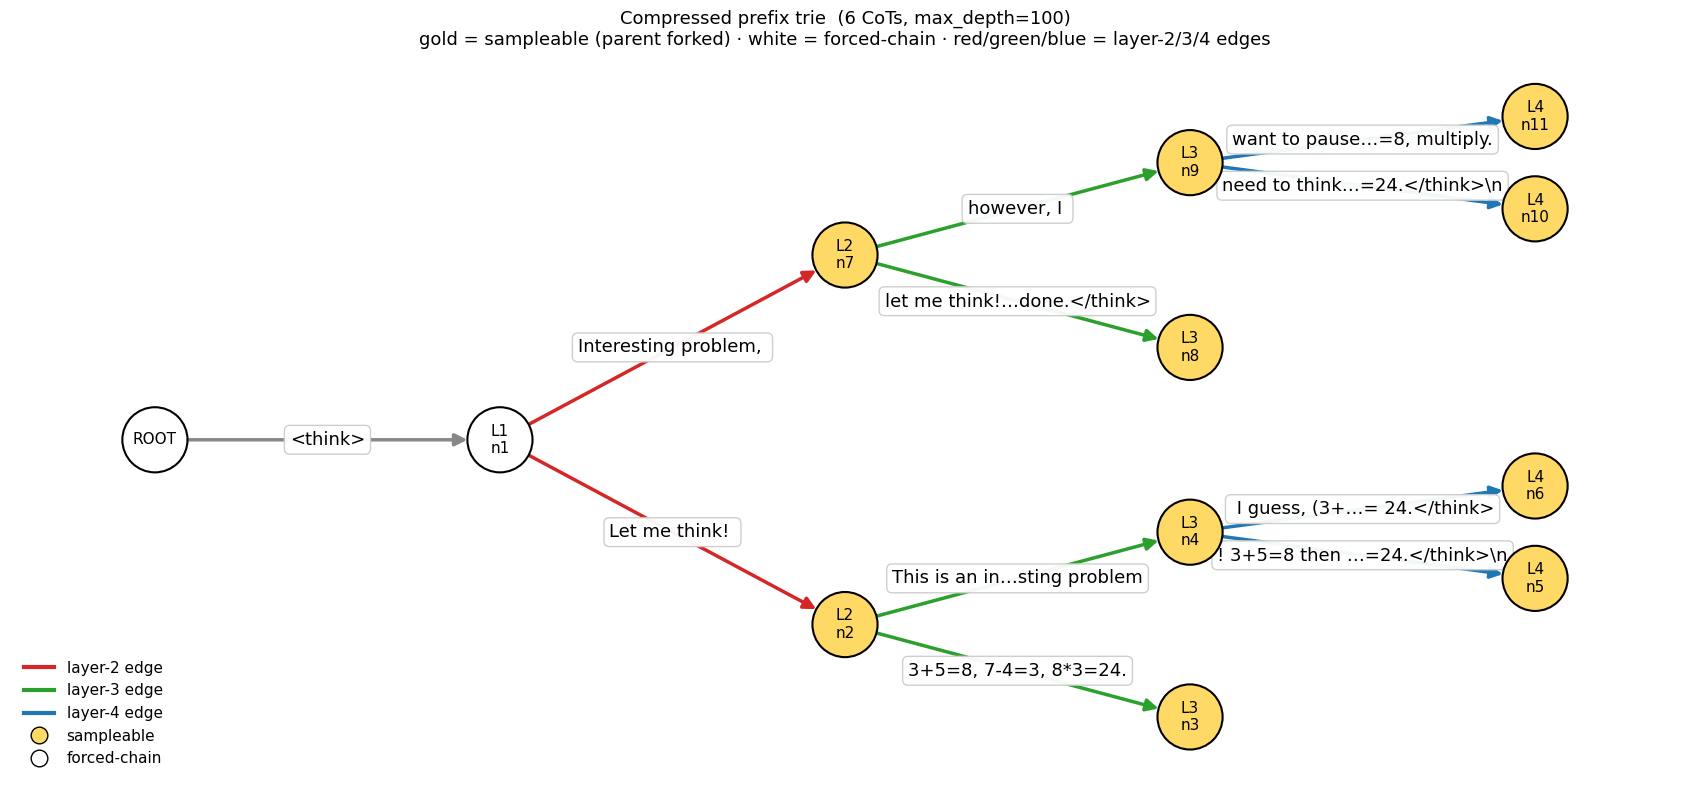

In [6]:
# =============================================================================
# Verify PrefixTrie.sample() — text output + readable trie diagram.
# =============================================================================
from collections import defaultdict
import numpy as np

from src.prefix_inject import visualize_prefix_trie

# ── A) TEXT — every layered prefix the trie can sample. ─────────────────────
print("All real-branch prefixes the trie can sample (max_layer=4):")
all_paths = trie.layered_prefixes(max_layer=4)
by_layer = defaultdict(list)
for s, lyr in all_paths:
    by_layer[lyr].append(s)
for lyr in sorted(by_layer):
    print(f"\n  layer {lyr}  ({len(by_layer[lyr])} node(s)):")
    for s in by_layer[lyr]:
        print(f"     {s!r}")

# 20 uniform draws at max_layer=3.
print("\n\n20 samples from trie.sample(rng, max_layer=3):")
rng = np.random.default_rng(0)
for _ in range(20):
    print(f"   {trie.sample(rng, max_layer=3)!r}")

# Empirical distribution check (5000 draws).
print("\nEmpirical sampling frequency over 5000 draws (max_layer=3):")
rng = np.random.default_rng(1)
freqs = defaultdict(int)
N = 5000
for _ in range(N):
    freqs[trie.sample(rng, max_layer=3)] += 1
pool = [s for s, lyr in all_paths if lyr <= 3]
print(f"   pool size = {len(pool)}, expected freq = {1.0/len(pool):.3f}")
for s in pool:
    print(f"     {freqs[s]/N:.3f}   {s!r}")

# ── B) DIAGRAM — horizontal layout, large fonts, full-prefix legend. ────────
visualize_prefix_trie(trie, orientation="horizontal", figsize=(17, 8))


In [ ]:
# Is the advantage computed across different model rollouts reasonable?